In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import pickle
import fasttext
import fasttext.util
import numpy as np

# Load your preprocessed dataset
data_path = r"C:\Users\PC\Downloads\your_preprocessed_data.xlsx"
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'
target_column = 'encoded_class'

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Save the text data to a temporary file for FastText
fasttext_input_path = r"C:\Users\PC\Downloads\fasttext_input.txt"
data[text_column].to_csv(fasttext_input_path, index=False, header=False)

# Step 1: Train the FastText model
print("Training FastText model...")
fasttext_model = fasttext.train_unsupervised(fasttext_input_path, model='skipgram', dim=100)
fasttext_model.save_model(r"C:\Users\PC\Downloads\fasttext_model.bin")

# Step 2: Generate FastText embeddings for each document
def get_fasttext_embeddings(text, model, vector_size=100):
    words = text.split()
    embeddings = np.zeros(vector_size)
    count = 0
    for word in words:
        embeddings += model.get_word_vector(word)
        count += 1
    if count > 0:
        embeddings /= count  # Average the embeddings
    return embeddings

# Apply FastText embeddings to each document
X_fasttext = np.array([get_fasttext_embeddings(text, fasttext_model) for text in data[text_column]])

# Step 3: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_fasttext, data[target_column], test_size=0.2, random_state=42)

# Step 4: Initialize and train the XGBoost model
print("Training XGBoost Model...")
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    'objective': 'multi:softmax',
    'eval_metric': 'mlogloss',
    'num_class': len(y_train.unique()),
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'nthread': 4
}

# Train the model
num_round = 100
xgb_model = xgb.train(params, dtrain, num_round)

# Step 5: Save the trained XGBoost model
model_path = r"C:\Users\PC\Downloads\xgboost_model_fasttext.pkl"
with open(model_path, 'wb') as f:
    pickle.dump(xgb_model, f)
print(f"Trained XGBoost model saved to {model_path}")

# Step 6: Evaluate the XGBoost model
y_pred_xgb = xgb_model.predict(dtest)

# Print evaluation metrics
accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb, average='weighted')
recall = recall_score(y_test, y_pred_xgb, average='weighted')
f1 = f1_score(y_test, y_pred_xgb, average='weighted')

print(f"XGBoost Accuracy: {accuracy * 100:.2f}%")
print(f"XGBoost Precision: {precision * 100:.2f}%")
print(f"XGBoost Recall: {recall * 100:.2f}%")
print(f"XGBoost F1 Score: {f1 * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


C:\Users\PC\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Training FastText model...
Training XGBoost Model...
Trained XGBoost model saved to C:\Users\PC\Downloads\xgboost_model_fasttext.pkl
XGBoost Accuracy: 93.77%
XGBoost Precision: 93.77%
XGBoost Recall: 93.77%
XGBoost F1 Score: 93.77%

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94     23238
           1       0.94      0.94      0.94     23171

    accuracy                           0.94     46409
   macro avg       0.94      0.94      0.94     46409
weighted avg       0.94      0.94      0.94     46409



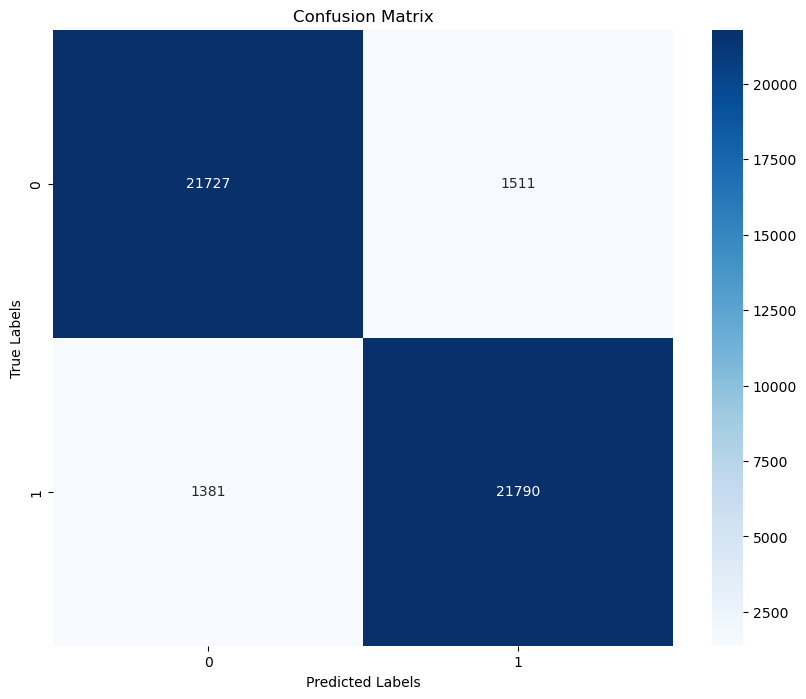

In [2]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=y_train.unique(), yticklabels=y_train.unique())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

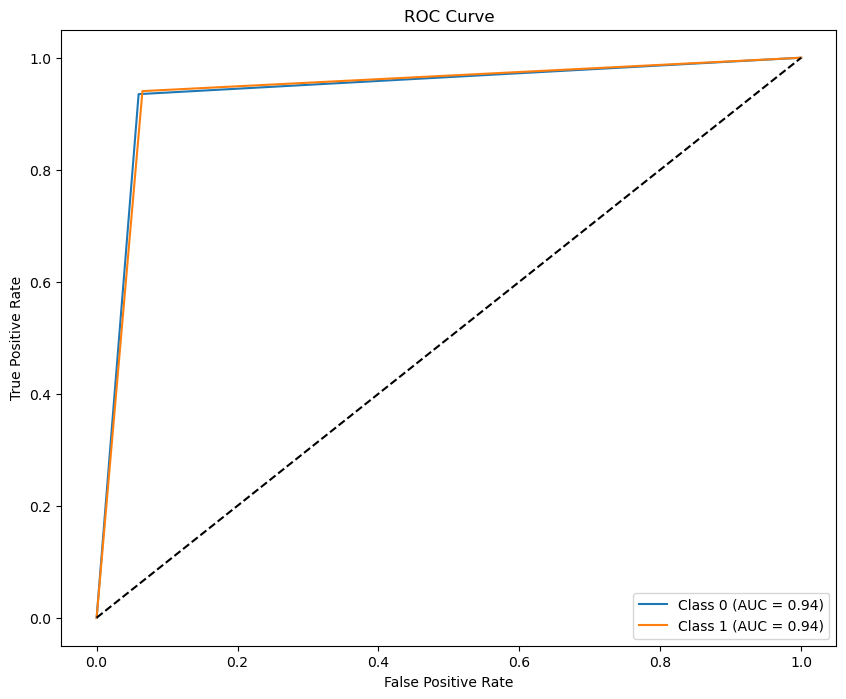

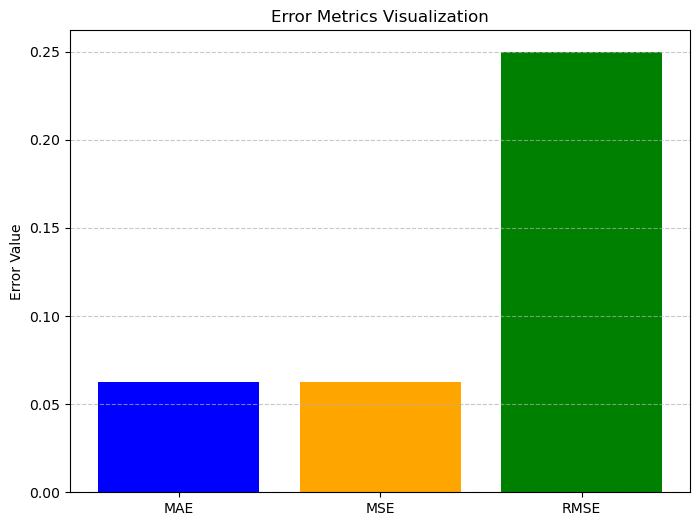

Mean Absolute Error (MAE): 0.06
Mean Squared Error (MSE): 0.06
Root Mean Squared Error (RMSE): 0.25


In [4]:
from sklearn.metrics import roc_curve, auc, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# ROC Curve
fpr = dict()
tpr = dict()
roc_auc = dict()

# Assuming y_test and y_pred_proba are available
y_pred_proba = xgb_model.predict(xgb.DMatrix(X_test))  # Predicted probabilities

# For multi-class, binarize the output
classes = np.unique(y_test)
for i in classes:
    fpr[i], tpr[i], _ = roc_curve((y_test == i).astype(int), y_pred_proba == i)
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in classes:
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# MAE, MSE, RMSE
mae = mean_absolute_error(y_test, y_pred_proba)
mse = mean_squared_error(y_test, y_pred_proba)
rmse = np.sqrt(mse)

# Visualization
metrics = ['MAE', 'MSE', 'RMSE']
values = [mae, mse, rmse]

plt.figure(figsize=(8, 6))
plt.bar(metrics, values, color=['blue', 'orange', 'green'])
plt.title('Error Metrics Visualization')
plt.ylabel('Error Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Training XGBoost Model with Evaluation...
[0]	train-mlogloss:0.63185	train-merror:0.10726	eval-mlogloss:0.63178	eval-merror:0.10681
[1]	train-mlogloss:0.58018	train-merror:0.09764	eval-mlogloss:0.58012	eval-merror:0.09843
[2]	train-mlogloss:0.53739	train-merror:0.09390	eval-mlogloss:0.53764	eval-merror:0.09505
[3]	train-mlogloss:0.49967	train-merror:0.09328	eval-mlogloss:0.49992	eval-merror:0.09449
[4]	train-mlogloss:0.46749	train-merror:0.09260	eval-mlogloss:0.46782	eval-merror:0.09257
[5]	train-mlogloss:0.43947	train-merror:0.09187	eval-mlogloss:0.43985	eval-merror:0.09220
[6]	train-mlogloss:0.41485	train-merror:0.09097	eval-mlogloss:0.41537	eval-merror:0.09168
[7]	train-mlogloss:0.39313	train-merror:0.08941	eval-mlogloss:0.39361	eval-merror:0.09003
[8]	train-mlogloss:0.37413	train-merror:0.08840	eval-mlogloss:0.37461	eval-merror:0.08897
[9]	train-mlogloss:0.35724	train-merror:0.08789	eval-mlogloss:0.35789	eval-merror:0.08843
[10]	train-mlogloss:0.34184	train-merror:0.08692	eval-mlog

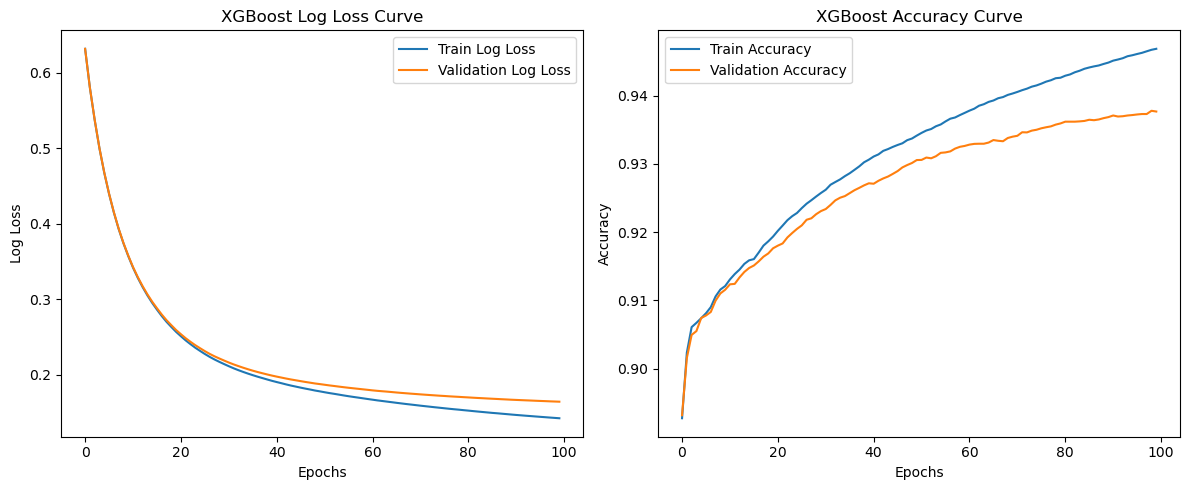

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import xgboost as xgb
import fasttext
import matplotlib.pyplot as plt

# Load your preprocessed dataset
data_path = r"C:\Users\PC\Downloads\your_preprocessed_data.xlsx"
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'
target_column = 'encoded_class'

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# FastText processing
fasttext_model = fasttext.load_model(r"C:\Users\PC\Downloads\fasttext_model.bin")

# Generate FastText embeddings
def get_fasttext_embeddings(text, model, vector_size=100):
    words = text.split()
    embeddings = np.zeros(vector_size)
    count = 0
    for word in words:
        embeddings += model.get_word_vector(word)
        count += 1
    if count > 0:
        embeddings /= count  # Average the embeddings
    return embeddings

# Apply FastText embeddings
X_fasttext = np.array([get_fasttext_embeddings(text, fasttext_model) for text in data[text_column]])
y = data[target_column]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_fasttext, y, test_size=0.2, random_state=42)

# Step 4 (Modified): Initialize and train the XGBoost model with evaluation
print("Training XGBoost Model with Evaluation...")
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

eval_list = [(dtrain, 'train'), (dtest, 'eval')]

params = {
    'objective': 'multi:softmax',
    'eval_metric': ['mlogloss', 'merror'],  # Track both log loss and classification error
    'num_class': len(y_train.unique()),
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'nthread': 4
}

# Train the model and capture evaluation results
num_round = 100
evals_result = {}  # Dictionary to store evaluation results

xgb_model = xgb.train(params, dtrain, num_round, evals=eval_list, evals_result=evals_result, verbose_eval=True)

# Plotting the Learning Curves
# Loss Curve (Log Loss)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(evals_result['train']['mlogloss'], label='Train Log Loss')
plt.plot(evals_result['eval']['mlogloss'], label='Validation Log Loss')
plt.xlabel('Epochs')
plt.ylabel('Log Loss')
plt.title('XGBoost Log Loss Curve')
plt.legend()

# Accuracy Curve (1 - Classification Error)
plt.subplot(1, 2, 2)
train_accuracy = [1 - err for err in evals_result['train']['merror']]
val_accuracy = [1 - err for err in evals_result['eval']['merror']]

plt.plot(train_accuracy, label='Train Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('XGBoost Accuracy Curve')
plt.legend()

plt.tight_layout()
plt.show()
